# Module 3 — Data Preprocessing
### Customer Personality Analysis

This notebook takes the raw dataset through a complete preprocessing
pipeline and produces a clean, analysis-ready dataset.

**Module 1 (Data Understanding) is already complete** — dataset loading,
inspection, the data dictionary, and the missing value / duplicate /
incorrect value / data quality reports were produced there and are not
repeated here. Only the key findings needed to justify preprocessing
decisions are referenced below.

Reusable pipeline logic lives in `preprocessing.py` (imported below) so the
same functions can run as a standalone script, in `main()`, or step-by-step
in this notebook — keeping the logic in one place and avoiding duplicate
code.

## 1. Load Dataset

We import the required libraries, load the raw dataset, and take a quick
look at its shape, structure, and summary statistics.

**Module 1 findings referenced here (not recomputed):**
- 2,240 rows, 29 columns
- 24 missing values, all in `Income`
- 0 duplicate rows
- 3 customers with an implausible birth year (age > 100)
- 1 extreme `Income` outlier (666,666)
- 7 rows with inconsistent `Marital_Status` categories (`Absurd`, `YOLO`, `Alone`)

In [10]:
# Import required libraries

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add the src directory to Python's search path
PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))

# Import the reusable preprocessing pipeline functions
from preprocessing import (
    PROJECT_DIR,
    RAW_DATA_DIR,
    CLEANED_DATA_DIR,
    REPORT_DIR,
    DATASET_PATH,
    CLEANED_DATASET_PATH,
    SPENDING_COLUMNS,
    CONSTANT_COLUMNS,
    load_data,
    handle_missing_values,
    remove_duplicates,
    convert_data_types,
    convert_dates,
    clean_categories,
    validate_age,
    detect_outliers,
    handle_outliers,
    remove_constant_columns,
    validate_dataset,
    save_dataset,
)

pd.set_option("display.max_columns", None)

In [11]:
# Load the raw dataset

df = load_data()

# Keep an untouched copy of the raw data for the before/after comparison
raw_df = df.copy()

print(f"Shape: {df.shape}")


Shape: (2240, 29)


In [12]:
# Structural overview

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [13]:
# First and last rows

display(df.head())
display(df.tail())


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1


In [14]:
# Summary statistics for numerical columns

df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## 2. Handle Missing Values

`Income` is the only column with missing values (24 rows, ~1.07%, per
Module 1). We impute those values using the **median**.

**Why median and not mean?** Income is right-skewed — a small number of
very high earners pull the mean upward. The median is robust to that
skew and better represents a "typical" customer's income, so filling
gaps with it avoids introducing artificial bias toward high-income
values.

In [15]:
# Missing values before imputation

missing_before = df.isnull().sum()
missing_before_pct = (missing_before / len(df) * 100).round(2)

missing_before_report = pd.DataFrame({
    "Missing Values": missing_before,
    "Percentage (%)": missing_before_pct
})

missing_before_report[missing_before_report["Missing Values"] > 0]


,Missing Values,Percentage (%)
Income,24,1.07


In [16]:
# Apply median imputation to Income

median_income = df["Income"].median()
print(f"Median Income used for imputation: {median_income}")

df = handle_missing_values(df)


Median Income used for imputation: 51381.5


In [17]:
# Verify no missing values remain

missing_after = df.isnull().sum().sum()
print(f"Total missing values after imputation: {missing_after}")


Total missing values after imputation: 0


## 3. Remove Duplicate Records

We check for fully duplicated rows and duplicated `ID` values, then
remove them. Module 1 found 0 duplicate rows, but we re-check here since
the dataset may have been re-loaded or changed.

In [18]:
# Detect duplicates before removal

duplicate_rows_before = df.duplicated().sum()
duplicate_ids_before = df["ID"].duplicated().sum()
rows_before_dedup = len(df)

print(f"Duplicate rows: {duplicate_rows_before}")
print(f"Duplicate IDs : {duplicate_ids_before}")


Duplicate rows: 0
Duplicate IDs : 0


In [19]:
# Remove duplicates (rows and duplicate IDs)

df = remove_duplicates(df)

rows_after_dedup = len(df)

print(f"Rows before: {rows_before_dedup}")
print(f"Rows after : {rows_after_dedup}")
print(f"Rows removed: {rows_before_dedup - rows_after_dedup}")


Rows before: 2240
Rows after : 2240
Rows removed: 0


## 4. Correct Data Types

`Education` and `Marital_Status` are converted to `category` dtype
(they hold a small, fixed set of text labels). Binary/flag columns
(`Kidhome`, `Teenhome`, the campaign-acceptance flags, `Complain`,
`Response`) are converted to a compact `int8`, since they only ever
hold small integer values.

In [20]:
# Data types before conversion

dtypes_before = df.dtypes.astype(str)

df = convert_data_types(df)

dtypes_after = df.dtypes.astype(str)

dtype_comparison = pd.DataFrame({
    "Column": dtypes_before.index,
    "Old Data Type": dtypes_before.values,
    "New Data Type": dtypes_after.reindex(dtypes_before.index).values
})

dtype_comparison


,Column,Old Data Type,New Data Type
0,ID,int64,int64
1,Year_Birth,int64,int64
2,Education,str,category
3,Marital_Status,str,category
4,Income,float64,float64
5,Kidhome,int64,int8
6,Teenhome,int64,int8
7,Dt_Customer,str,str
8,Recency,int64,int64
9,MntWines,int64,int64


## 5. Convert Dates

`Dt_Customer` is stored as text (`DD-MM-YYYY`). We convert it to a proper
`datetime` type. Any value that fails to parse becomes `NaT` and that row
is dropped, since an invalid enrollment date can't be trusted for
downstream analysis. We then extract `Enrollment_Year` and
`Enrollment_Month` as separate columns.

In [21]:
# Convert Dt_Customer to datetime and extract year/month

rows_before_dates = len(df)

df = convert_dates(df)

rows_after_dates = len(df)
invalid_dates_removed = rows_before_dates - rows_after_dates

print(f"Rows with invalid dates removed: {invalid_dates_removed}")
print(f"Dt_Customer dtype: {df['Dt_Customer'].dtype}")

df[["Dt_Customer", "Enrollment_Year", "Enrollment_Month"]].head()


Rows with invalid dates removed: 0
Dt_Customer dtype: datetime64[us]


,Dt_Customer,Enrollment_Year,Enrollment_Month
0,2012-09-04,2012,9
1,2014-03-08,2014,3
2,2013-08-21,2013,8
3,2014-02-10,2014,2
4,2014-01-19,2014,1


## 6. Standardize Categories

We clean `Education` and `Marital_Status` by stripping extra whitespace
and applying title case. We then merge the inconsistent `Marital_Status`
values found in Module 1 (`Alone`, `YOLO`, `Absurd`) into `Single`, since
none of them represent a genuine, distinct relationship status.

In [22]:
# Unique category values BEFORE cleaning

print("Education (before):", sorted(df["Education"].astype(str).unique()))
print("Marital_Status (before):", sorted(df["Marital_Status"].astype(str).unique()))


Education (before): ['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']
Marital_Status (before): ['Absurd', 'Alone', 'Divorced', 'Married', 'Single', 'Together', 'Widow', 'YOLO']


In [23]:
# Clean and standardize categorical columns

df = clean_categories(df)


In [24]:
# Unique category values AFTER cleaning

print("Education (after):", sorted(df["Education"].astype(str).unique()))
print("Marital_Status (after):", sorted(df["Marital_Status"].astype(str).unique()))


Education (after): ['2N Cycle', 'Basic', 'Graduation', 'Master', 'Phd']
Marital_Status (after): ['Divorced', 'Married', 'Single', 'Together', 'Widow']


## 7. Validate Customer Age

We derive an `Age` column from `Year_Birth` (using 2014, the latest
enrollment year in the dataset, as the reference point). Records with an
age above 100, below 18, or a birth year in the future are treated as
unrealistic and removed.

In [25]:
# Preview age issues before removal

from preprocessing import CURRENT_YEAR

temp_age = CURRENT_YEAR - df["Year_Birth"]  # temporary, for reporting only

age_over_100 = (temp_age > 100).sum()
age_under_18 = (temp_age < 18).sum()
future_birth_year = (df["Year_Birth"] > CURRENT_YEAR).sum()

print(f"Age > 100        : {age_over_100}")
print(f"Age < 18         : {age_under_18}")
print(f"Future birth year: {future_birth_year}")


Age > 100        : 3
Age < 18         : 0
Future birth year: 0


In [26]:
# Create Age column and remove unrealistic ages

rows_before_age = len(df)

df = validate_age(df)

rows_after_age = len(df)
unrealistic_ages_removed = rows_before_age - rows_after_age

print(f"Records removed for unrealistic age: {unrealistic_ages_removed}")
print(f"Age range after cleaning: {df['Age'].min()} - {df['Age'].max()}")


Records removed for unrealistic age: 3
Age range after cleaning: 18 - 74


## 8. Detect Outliers

We inspect `Income` and the six spending columns (`MntWines`,
`MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`,
`MntGoldProds`) for outliers using boxplots, the IQR method, and an
optional Z-score check.

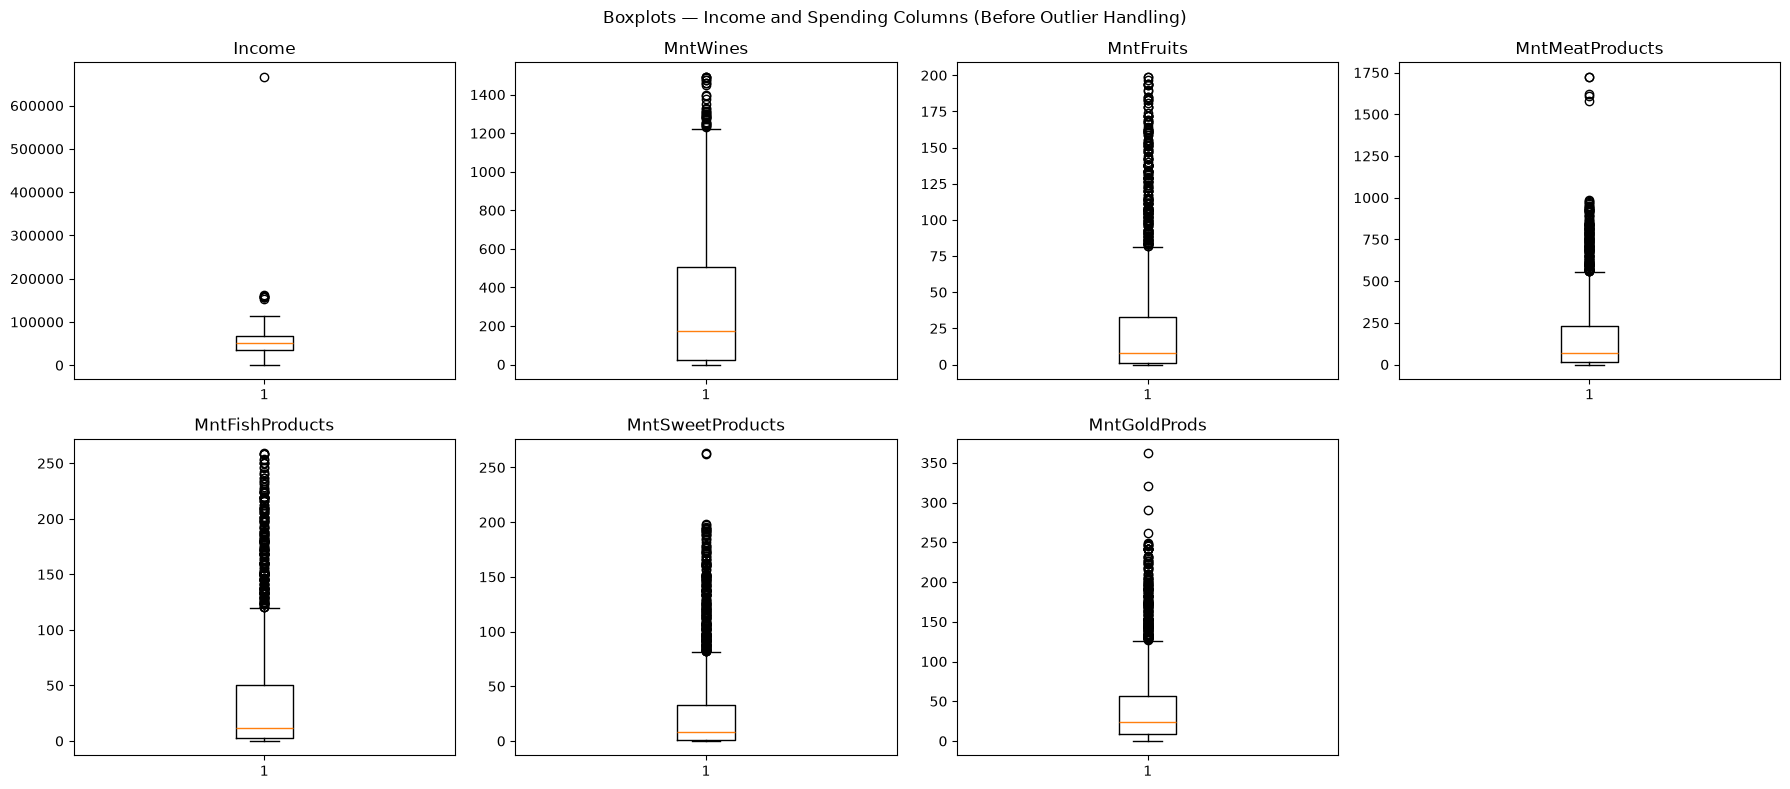

In [27]:
# Boxplots for Income and spending columns

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(SPENDING_COLUMNS):
    axes[i].boxplot(df[column].dropna())
    axes[i].set_title(column)

# Hide the unused 8th subplot
axes[-1].axis("off")

fig.suptitle("Boxplots — Income and Spending Columns (Before Outlier Handling)")
plt.tight_layout()
plt.show()


In [28]:
# IQR-based outlier summary

outlier_summary = detect_outliers(df, SPENDING_COLUMNS)
outlier_summary


,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Income,35523.0,68281.0,32758.0,-13614.0,117418.0,8
1,MntWines,24.0,504.0,480.0,-696.0,1224.0,35
2,MntFruits,1.0,33.0,32.0,-47.0,81.0,226
3,MntMeatProducts,16.0,232.0,216.0,-308.0,556.0,174
4,MntFishProducts,3.0,50.0,47.0,-67.5,120.5,223
5,MntSweetProducts,1.0,33.0,32.0,-47.0,81.0,248
6,MntGoldProds,9.0,56.0,47.0,-61.5,126.5,206


In [29]:
# Optional: Z-score based outlier check (|z| > 3)

zscore_records = []
for column in SPENDING_COLUMNS:
    z_scores = (df[column] - df[column].mean()) / df[column].std()
    zscore_outlier_count = (z_scores.abs() > 3).sum()
    zscore_records.append({"Variable": column, "Z-score Outlier Count": zscore_outlier_count})

zscore_summary = pd.DataFrame(zscore_records)
zscore_summary


,Variable,Z-score Outlier Count
0,Income,8
1,MntWines,16
2,MntFruits,64
3,MntMeatProducts,37
4,MntFishProducts,58
5,MntSweetProducts,62
6,MntGoldProds,43


## 9. Handle Outliers

**Income** is winsorized — values are clipped to the IQR lower/upper
bounds — because the extreme Income value (666,666) found in Module 1 is
almost certainly a data entry error, and it would distort any income-based
analysis if left unchanged.

**Spending outliers are kept.** A customer spending heavily on wine or
meat is plausible real behavior, not an error, so clipping those values
would remove genuine high-value customer signal. We only treat a
spending value as impossible if it's negative — a check confirmed
there are none.

In [30]:
# Confirm no impossible (negative) spending values exist

negative_spending = (df[SPENDING_COLUMNS[1:]] < 0).sum().sum()
print(f"Negative spending values found: {negative_spending}")


Negative spending values found: 0


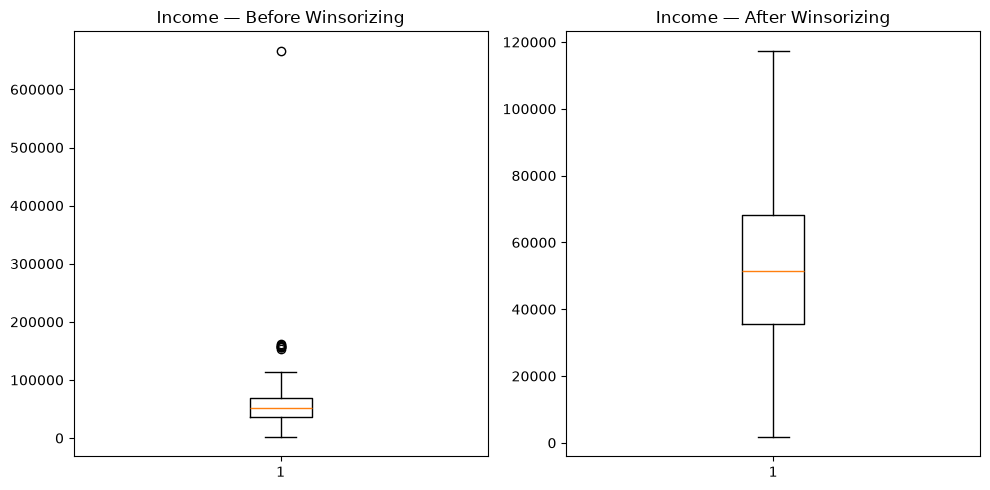

In [31]:
# Boxplot of Income BEFORE winsorizing

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(df["Income"].dropna())
axes[0].set_title("Income — Before Winsorizing")

df = handle_outliers(df, column="Income")

axes[1].boxplot(df["Income"].dropna())
axes[1].set_title("Income — After Winsorizing")

plt.tight_layout()
plt.show()


## 10. Remove Constant Features

`Z_CostContact` and `Z_Revenue` hold the same value for every single
customer. A column that never varies carries no analytical or predictive
value, so both are dropped.

In [32]:
# Confirm the columns are constant, then remove them

for column in CONSTANT_COLUMNS:
    print(f"{column} unique values: {df[column].unique()}")

df = remove_constant_columns(df)

print(f"\nRemaining columns: {df.shape[1]}")


Z_CostContact unique values: [3]
Z_Revenue unique values: [11]

Remaining columns: 30


## 11. Final Validation

A final checklist confirms that every preprocessing step succeeded:
missing values, duplicates, data types, dates, categories, and outliers.

In [33]:
# Run the final validation checklist

validation_checklist = validate_dataset(df)
validation_checklist


,Check,Passed
0,No missing values in Income,True
1,No duplicate rows,True
2,No duplicate IDs,True
3,Dt_Customer is datetime,True
4,All ages between 18 and 100,True
5,No constant Z_ columns,True


## 12. Before vs After Comparison

The table below summarizes how the dataset changed from raw to cleaned.
Row count dropped due to duplicate removal, invalid dates, and unrealistic
ages; column count changed due to the two constant columns being dropped
and `Enrollment_Year`, `Enrollment_Month`, and `Age` being added.

In [34]:
# Recompute a few "before" stats from the untouched raw copy

raw_missing = raw_df.isnull().sum().sum()
raw_duplicates = raw_df.duplicated().sum()
raw_invalid_ages = ((CURRENT_YEAR - raw_df["Year_Birth"] > 100)
                     | (CURRENT_YEAR - raw_df["Year_Birth"] < 18)).sum()
raw_constant_cols = len(CONSTANT_COLUMNS)
raw_outliers = detect_outliers(raw_df, SPENDING_COLUMNS)["Outlier Count"].sum()

final_outliers = detect_outliers(df, [c for c in SPENDING_COLUMNS if c in df.columns])["Outlier Count"].sum()

comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Records",
        "Invalid Ages",
        "Constant Columns",
        "Outliers (IQR, spending columns)"
    ],
    "Before": [
        raw_df.shape[0],
        raw_df.shape[1],
        raw_missing,
        raw_duplicates,
        raw_invalid_ages,
        raw_constant_cols,
        raw_outliers
    ],
    "After": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        0,
        0,
        final_outliers
    ]
})

comparison


,Metric,Before,After
0,Rows,2240,2237
1,Columns,29,30
2,Missing Values,24,0
3,Duplicate Records,0,0
4,Invalid Ages,3,0
5,Constant Columns,2,0
6,"Outliers (IQR, spending columns)",1123,1112


**Explanation:** rows decreased slightly as invalid records (duplicates,
unparseable dates, unrealistic ages) were removed. Missing values and
duplicates dropped to zero. The two constant `Z_` columns were removed,
while `Age`, `Enrollment_Year`, and `Enrollment_Month` were added — a net
column change. Income outliers dropped to 0 after winsorizing; spending
outliers remain by design, since they reflect genuine customer behavior
rather than data errors.

## 13. Save Clean Dataset

The cleaned dataset is saved to `03_Cleaned_Data/customer_personality_cleaned.csv`.

In [35]:
# Save the cleaned dataset

cleaned_path = save_dataset(df)

print("✅ Cleaned dataset saved!")
print(cleaned_path)
print(f"Final shape: {df.shape}")


✅ Cleaned dataset saved!
/home/xploit/Downloads/Day-6/03_Cleaned_Data/customer_personality_cleaned.csv
Final shape: (2237, 30)


## 14. Export Reports

Three reports are generated and saved to `04_Preprocessing_Report/`:
- `missing_values_after_cleaning.xlsx`
- `data_validation_report.xlsx`
- `before_after_comparison.xlsx`

In [36]:
# Report 1: Missing values after cleaning

missing_after_cleaning = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

output_path = REPORT_DIR / "missing_values_after_cleaning.xlsx"
output_path.parent.mkdir(parents=True, exist_ok=True)
missing_after_cleaning.to_excel(output_path, index=False)

print("✅ Missing Values (After Cleaning) Report Saved!")
print(output_path)


✅ Missing Values (After Cleaning) Report Saved!
/home/xploit/Downloads/Day-6/04_Preprocessing_Report/missing_values_after_cleaning.xlsx


In [37]:
# Report 2: Data validation report

output_path = REPORT_DIR / "data_validation_report.xlsx"
output_path.parent.mkdir(parents=True, exist_ok=True)
validation_checklist.to_excel(output_path, index=False)

print("✅ Data Validation Report Saved!")
print(output_path)


✅ Data Validation Report Saved!
/home/xploit/Downloads/Day-6/04_Preprocessing_Report/data_validation_report.xlsx


In [38]:
# Report 3: Before vs after comparison

output_path = REPORT_DIR / "before_after_comparison.xlsx"
output_path.parent.mkdir(parents=True, exist_ok=True)
comparison.to_excel(output_path, index=False)

print("✅ Before vs After Comparison Report Saved!")
print(output_path)


✅ Before vs After Comparison Report Saved!
/home/xploit/Downloads/Day-6/04_Preprocessing_Report/before_after_comparison.xlsx


## 15. Standalone Preprocessing Script

All of the pipeline logic used above lives in **`preprocessing.py`**,
located alongside this notebook. It exposes the same functions imported
at the top of this notebook (`load_data`, `handle_missing_values`,
`remove_duplicates`, `convert_data_types`, `convert_dates`,
`clean_categories`, `validate_age`, `detect_outliers`, `handle_outliers`,
`remove_constant_columns`, `validate_dataset`, `save_dataset`) plus a
`main()` function that chains them into a complete pipeline.

It can be run independently of this notebook:

```bash
python preprocessing.py
```

This will load the raw data, run every preprocessing step, print a
summary, and save the cleaned dataset — without needing Jupyter.

## 16. Preprocessing Summary

- **Missing values:** the 24 missing `Income` values were filled with the
  median.
- **Duplicates:** checked for duplicate rows and IDs; none remained after
  removal.
- **Data types:** `Education`/`Marital_Status` converted to `category`;
  flag columns converted to `int8`.
- **Dates:** `Dt_Customer` converted to `datetime`; `Enrollment_Year` and
  `Enrollment_Month` extracted.
- **Categories:** whitespace/casing standardized; `Alone`, `YOLO`, and
  `Absurd` merged into `Single`.
- **Age:** an `Age` column was derived and records with unrealistic ages
  were removed.
- **Outliers:** detected via IQR (and an optional Z-score check) across
  `Income` and six spending columns; `Income` was winsorized, spending
  outliers were kept as genuine customer behavior.
- **Constant columns:** `Z_CostContact` and `Z_Revenue` were dropped.
- **Final validation:** all checklist items passed.

The cleaned dataset is saved at
`03_Cleaned_Data/customer_personality_cleaned.csv`, and all preprocessing
reports are saved under `04_Preprocessing_Report/`. The dataset is now
ready for the next stage of analysis or modeling.